In [90]:
import numpy as np
import pandas as pd
import os
import pathlib

from tqdm import tqdm
import warnings

from skimage import util
from skimage.filters import threshold_otsu, gaussian, threshold_isodata, threshold_minimum, threshold_triangle, threshold_otsu, threshold_mean, threshold_li, try_all_threshold, threshold_yen
from skimage.segmentation import clear_border, watershed
from skimage.measure import label, regionprops, regionprops_table
from skimage.morphology import remove_small_holes, remove_small_objects, opening, ball, dilation, erosion
from skimage.transform import rescale
from skimage.feature import peak_local_max
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt
from scipy import ndimage as ndi

from skimage.filters import median as median_filter
from skimage.morphology import square
from tifffile import imread
import tifffile

import napari

warnings.filterwarnings("ignore")

In [ ]:

import liffile

lif_path = r"z:\Marina\Stellaris\2026.03.10_CART\CART_FL12_ToQuantify\CART_exp1_day6.lif"

with liffile.LifFile(lif_path) as lif:
    img = lif.images[0]
    print(f"Name:  {img.name}")
    print(f"dims:  {img.dims}")
    print(f"shape: {img.shape}")
    data = img.asarray()

print(f"\nLoaded array shape: {data.shape}")


Name:  FL12_day6_ARi1
dims:  ('C', 'Z', 'Y', 'X')
shape: (5, 33, 2780, 4752)

Loaded array shape: (5, 33, 2780, 4752)
test shape (after Z max-projection): (5, 1, 2780, 4752)
Axes order: ('C', 'Z', 'Y', 'X')  →  Z axis 1 collapsed to 1


In [10]:

# Max-project along the Z axis (keepdims so Z dim stays as 1)
z_axis = img.dims.index('Z')
test_sum = np.sum(data, axis=z_axis, keepdims=True)
test_max = np.max(data, axis=z_axis, keepdims=True)
print(f"test shape (after Z max-projection): {test_sum.shape}")
print(f"Axes order: {img.dims}  →  Z axis {z_axis} collapsed to 1")


test shape (after Z max-projection): (5, 1, 2780, 4752)
Axes order: ('C', 'Z', 'Y', 'X')  →  Z axis 1 collapsed to 1


In [13]:
test_sum.shape

(5, 1, 2780, 4752)

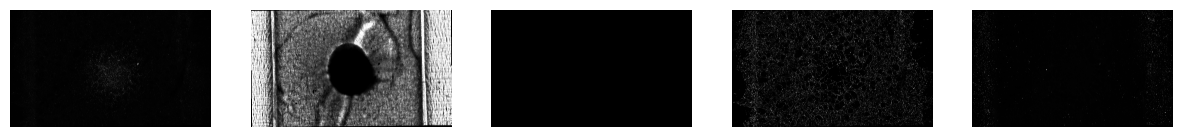

In [20]:
fig , ax = plt.subplots(ncols = test_sum.shape[0], figsize=(15,3))
channel = 0  # change to 0-4 to pick a channel
for i in range(test_sum.shape[0]):
    ax[i].imshow(test_sum[i, 0, :, :], cmap='gray')
    ax[i].axis('off')

In [78]:
vasculature = test_max[3, 0, :, :]
vasculature_median = median_filter(vasculature, footprint=square(7))
smooth_vasculature = gaussian(vasculature_median, sigma=3)
segmented_vasculature = smooth_vasculature>threshold_triangle(smooth_vasculature)

In [79]:
device = test_max[1, 0, :, :]
clipped = np.clip(device, np.percentile(device, 25), np.percentile(device, 90))
smoothed = gaussian(clipped, sigma=7)
gel = util.invert(smoothed > threshold_mean(smoothed))
gel = remove_small_holes(gel, max_size=500000)

# Keep only the largest connected component
labeled_gel = label(gel)
props = pd.DataFrame(regionprops_table(labeled_gel, properties=("label", "area")))
largest_label = props.loc[props["area"].idxmax(), "label"]
gel = labeled_gel == largest_label


In [95]:
tcells = test_max[0, 0, :, :]
cart = test_max[-1, 0, :, :]
segmented_t_cells = tcells > threshold_yen(tcells)
segmented_cart_cells = cart> threshold_otsu(cart)

In [ ]:
tumour = device < threshold_minimum(device)
labeled_tumour = label(tumour)
props = pd.DataFrame(regionprops_table(labeled_tumour, properties=("label", "area")))
largest_label = props.loc[props["area"].idxmax(), "label"]
tumour = labeled_tumour == largest_label


In [96]:

def _cell_counts_in_region(cell_mask, region_mask):
    """Returns (n_cells_inside, n_cells_outside, pixels_inside, pixels_outside).
    Cell membership is determined by centroid location."""
    labeled = label(cell_mask)
    n_total = int(labeled.max())
    if n_total == 0:
        return 0, 0, 0, 0

    props_df = pd.DataFrame(regionprops_table(labeled, properties=("centroid",)))
    rows = np.clip(np.round(props_df["centroid-0"].values).astype(int), 0, region_mask.shape[0] - 1)
    cols = np.clip(np.round(props_df["centroid-1"].values).astype(int), 0, region_mask.shape[1] - 1)
    in_region = region_mask.astype(bool)[rows, cols]

    n_in  = int(in_region.sum())
    n_out = n_total - n_in
    pix_in  = int(np.sum(cell_mask.astype(bool) & region_mask.astype(bool)))
    pix_out = int(np.sum(cell_mask.astype(bool) & ~region_mask.astype(bool)))
    return n_in, n_out, pix_in, pix_out


regions = {
    "gel":         gel.astype(bool),
    "tumour":      tumour.astype(bool),
    "vasculature": segmented_vasculature.astype(bool),
}

records = []
for cell_name, cell_mask in [("CART cells", segmented_cart_cells),
                              ("T cells",    segmented_t_cells)]:
    cell_mask = cell_mask.astype(bool)
    labeled_cells = label(cell_mask)
    n_total  = int(labeled_cells.max())
    pix_total = int(cell_mask.sum())

    records.append(dict(cell_type=cell_name, region="overall", location="all",
                        cell_count=n_total, positive_pixels=pix_total))

    for region_name, region_mask in regions.items():
        n_in, n_out, pix_in, pix_out = _cell_counts_in_region(cell_mask, region_mask)
        records.append(dict(cell_type=cell_name, region=region_name, location="inside",
                            cell_count=n_in,  positive_pixels=pix_in))
        records.append(dict(cell_type=cell_name, region=region_name, location="outside",
                            cell_count=n_out, positive_pixels=pix_out))

summary = pd.DataFrame(records)
summary


,cell_type,region,location,cell_count,positive_pixels
0,CART cells,overall,all,9349,117651
1,CART cells,gel,inside,1640,18236
2,CART cells,gel,outside,7709,99415
3,CART cells,tumour,inside,19,95
4,CART cells,tumour,outside,9330,117556
5,CART cells,vasculature,inside,5947,72319
6,CART cells,vasculature,outside,3402,45332
7,T cells,overall,all,15348,68756
8,T cells,gel,inside,12900,64947
9,T cells,gel,outside,2448,3809


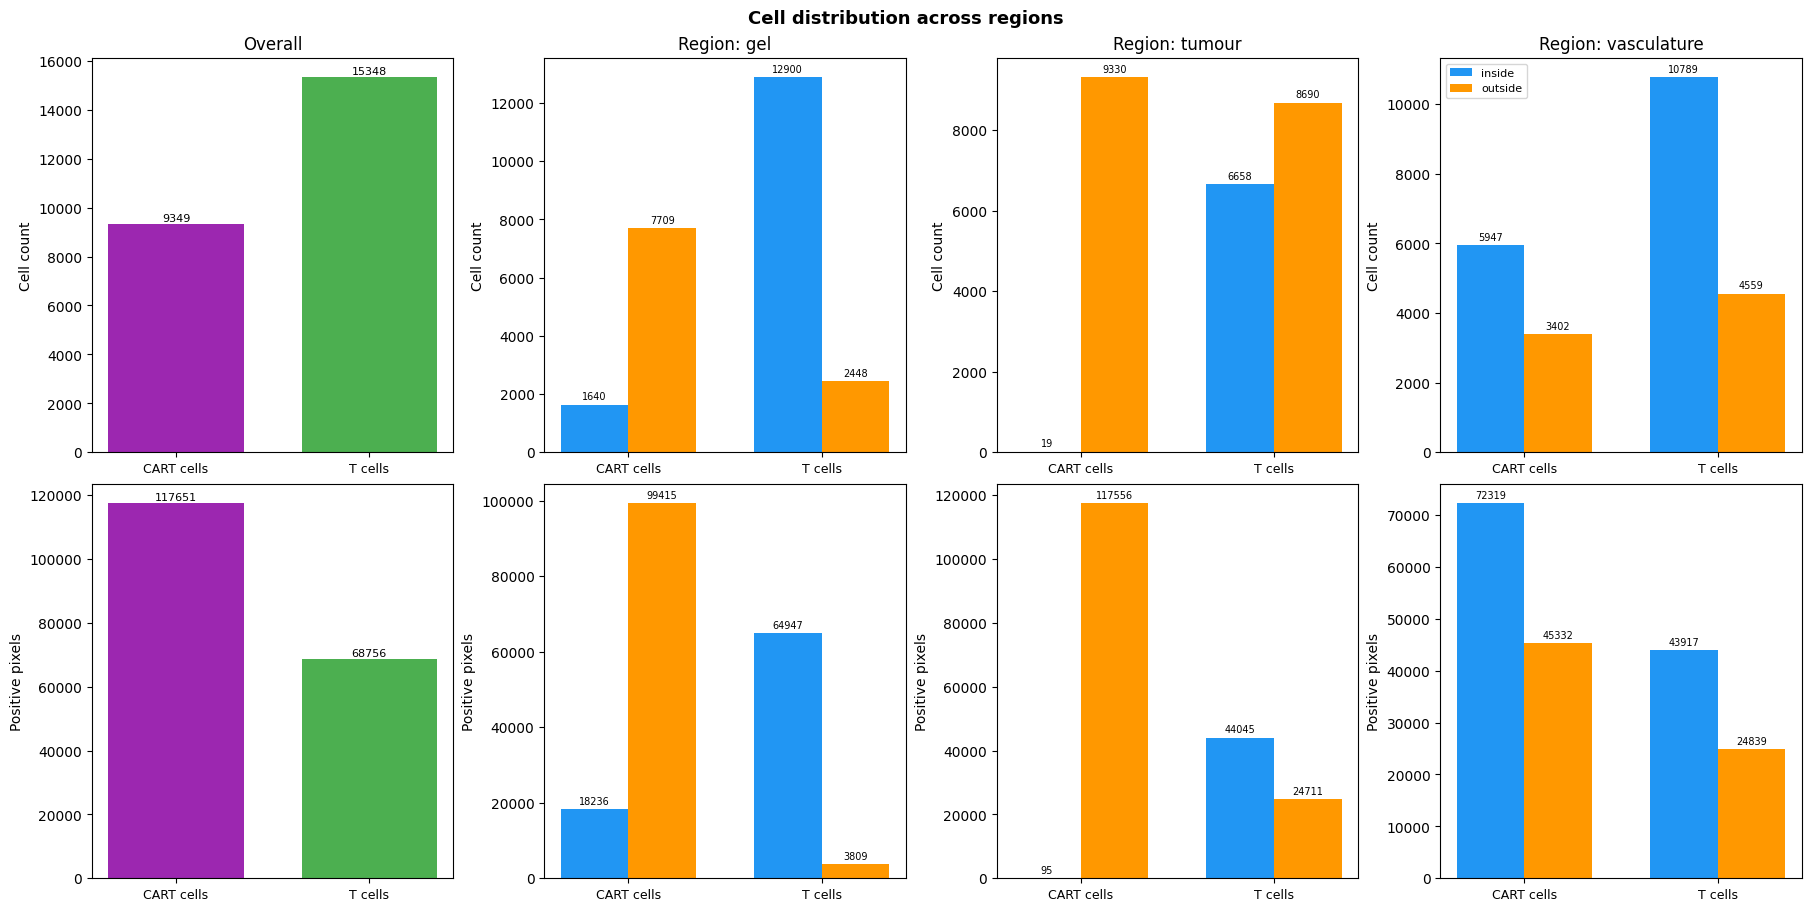

In [97]:

region_names = ["gel", "tumour", "vasculature"]
cell_types   = ["CART cells", "T cells"]
colors       = {"inside": "#2196F3", "outside": "#FF9800"}
x            = np.arange(len(cell_types))
width        = 0.35

fig, axes = plt.subplots(2, len(region_names) + 1, figsize=(18, 9), constrained_layout=True)
metrics = [("cell_count", "Cell count"), ("positive_pixels", "Positive pixels")]

# column 0: overall totals
for row, (metric, ylabel) in enumerate(metrics):
    ax = axes[row, 0]
    vals = [
        summary.loc[(summary.cell_type == ct) & (summary.region == "overall"), metric].values[0]
        for ct in cell_types
    ]
    bars = ax.bar(x, vals, width * 2, color=["#9C27B0", "#4CAF50"])
    ax.set_xticks(x)
    ax.set_xticklabels(cell_types, fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title("Overall" if row == 0 else "")
    ax.bar_label(bars, fmt="%d", fontsize=8)

# columns 1-3: inside vs outside per region
for col, region in enumerate(region_names, start=1):
    for row, (metric, ylabel) in enumerate(metrics):
        ax = axes[row, col]
        vals_in = [
            summary.loc[(summary.cell_type == ct) & (summary.region == region) & (summary.location == "inside"), metric].values[0]
            for ct in cell_types
        ]
        vals_out = [
            summary.loc[(summary.cell_type == ct) & (summary.region == region) & (summary.location == "outside"), metric].values[0]
            for ct in cell_types
        ]
        b1 = ax.bar(x - width / 2, vals_in,  width, label="inside",  color=colors["inside"])
        b2 = ax.bar(x + width / 2, vals_out, width, label="outside", color=colors["outside"])
        ax.set_xticks(x)
        ax.set_xticklabels(cell_types, fontsize=9)
        ax.set_ylabel(ylabel)
        ax.set_title(f"Region: {region}" if row == 0 else "")
        ax.bar_label(b1, fmt="%d", fontsize=7, padding=2)
        ax.bar_label(b2, fmt="%d", fontsize=7, padding=2)
        if col == len(region_names) and row == 0:
            ax.legend(fontsize=8)

fig.suptitle("Cell distribution across regions", fontsize=13, fontweight="bold")
plt.show()
